# Load the necessary modules

In [2]:
import tifffile
import matplotlib.pyplot as plt
from selfphish.utils import nor_phase
from selfphish.ganrec import GANphase

2025-07-23 14:38:10.844218: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753295891.980019 3828776 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753295892.255237 3828776 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753295895.232277 3828776 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753295895.232316 3828776 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753295895.232325 3828776 computation_placer.cc:177] computation placer alr

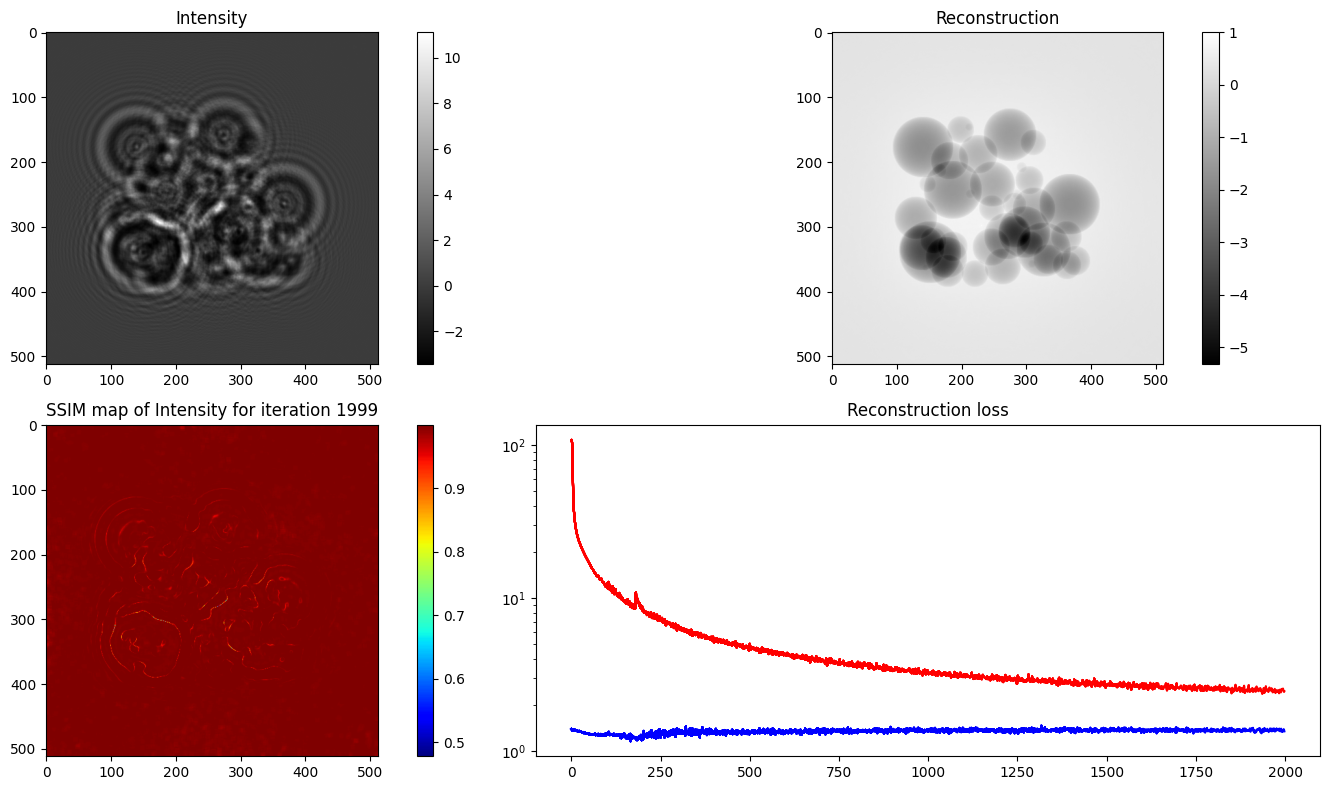

<Figure size 640x480 with 0 Axes>

Reconstruction Progress: 100%|█████████▉| 1999/2000 [01:23<00:00, 34.50it/s, D_loss=1.37, G_loss=2.53]

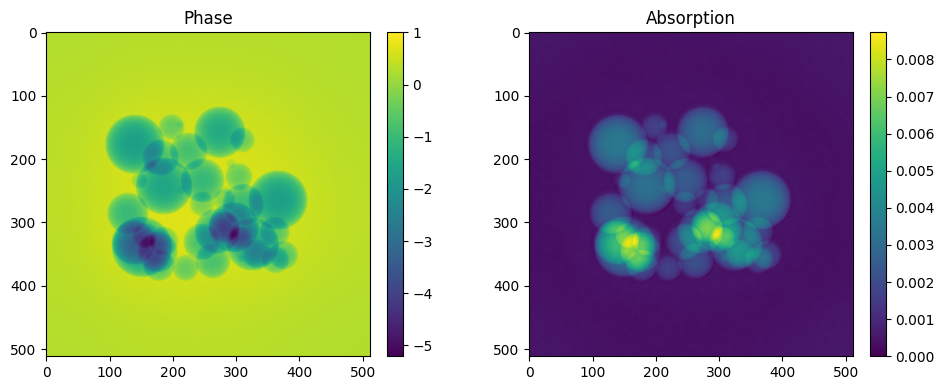

In [2]:
energy = 15 # in keV
z = 0.05 # in m
pv = 1e-7 # in m
abs_ratio = 0.001 # ratio of absorption to phase
iter_num = 2000
data = tifffile.imread('./test_data/hologram_sphere_e15k_z50mm_p100nm_abs001.tiff')
data = nor_phase(data)
abs, phase = GANphase(data, energy, z, pv, abs_ratio=abs_ratio, iter_num=iter_num).recon

# Subplot both phase and abs
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
im0 = axs[0].imshow(phase)
axs[0].set_title('Phase')
fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)
im1 = axs[1].imshow(abs)
axs[1].set_title('Absorption')
fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

tifffile.imwrite('./test_results/sphere_phase_e15k_z50mm_p100nm_abs001.tiff', phase)
tifffile.imwrite('./test_results/sphere_abs_e15k_z50mm_p100nm_abs001.tiff', abs)

Found result files: ['../examples/test_results/sphere_phase_e15k_z100mm_p100nm_abs001.tiff', '../examples/test_results/sphere_phase_e15k_z10mm_p100nm_abs001.tiff', '../examples/test_results/sphere_phase_e15k_z1mm_p100nm_abs001.tiff', '../examples/test_results/sphere_phase_e15k_z50mm_p100nm_abs001.tiff', '../examples/test_results/sphere_phase_e15k_z5mm_p100nm_abs001.tiff']


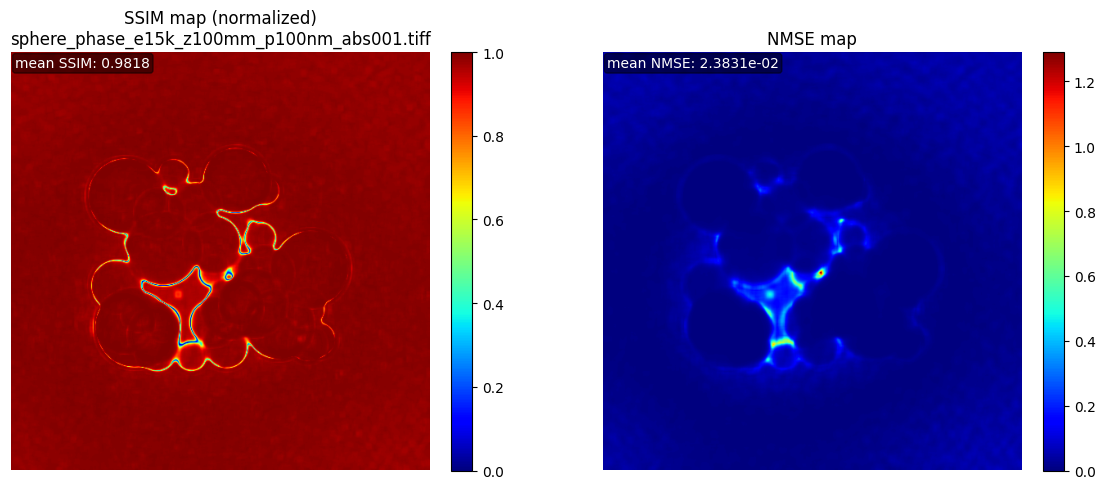

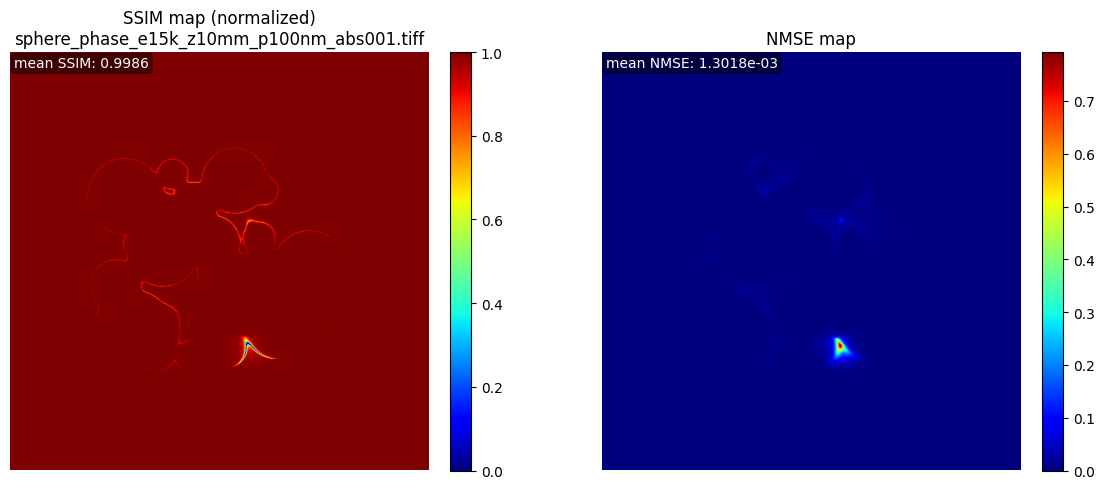

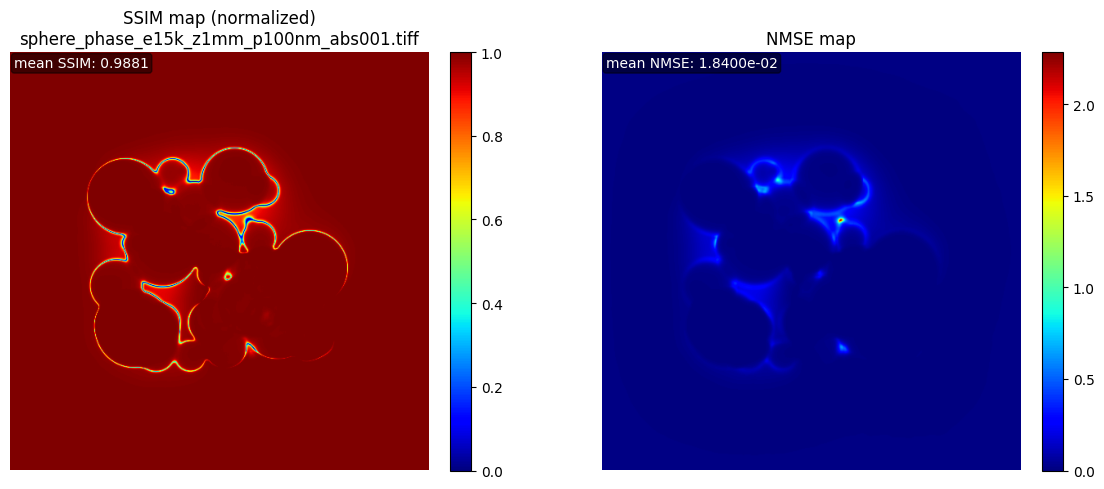

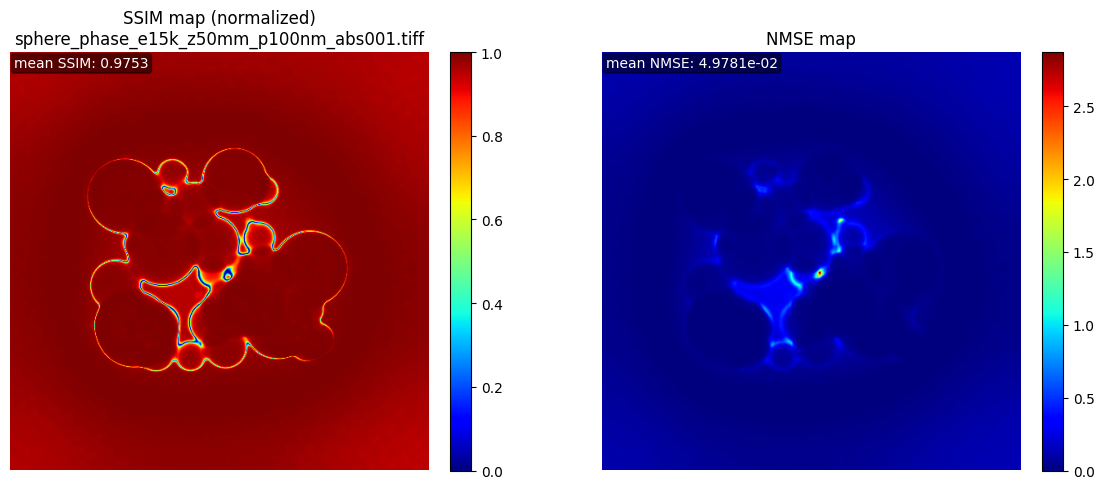

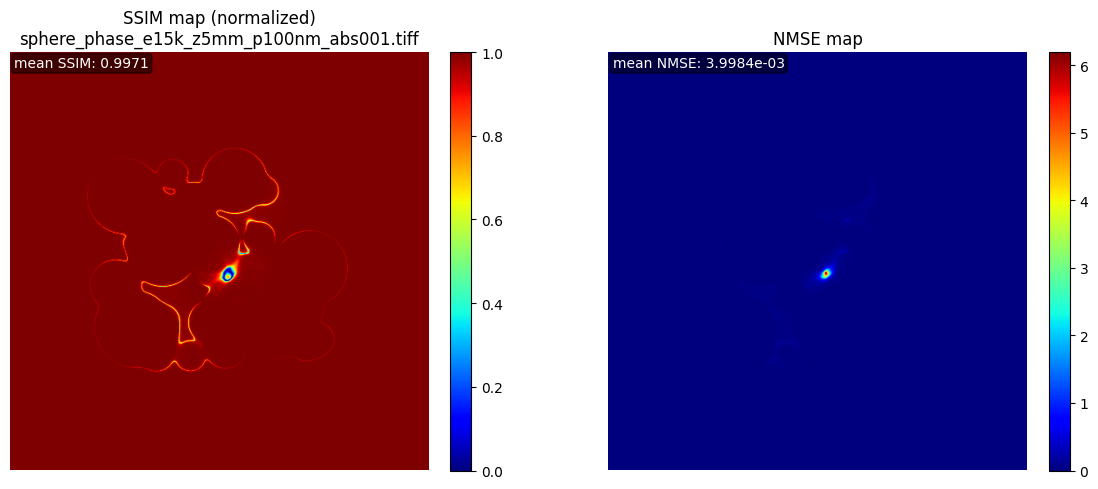

In [8]:
import glob
import numpy as np
from scipy.ndimage import uniform_filter
from skimage.metrics import structural_similarity as ssim

# Find all sphere_phase* files in test_results
img_f = tifffile.imread('../examples/test_data/phase_sphere.tiff')
result_files = sorted(glob.glob('../examples/test_results/sphere_phase*.tiff'))
print('Found result files:', result_files)


def compute_local_nmse(x_recon, x_true, window_size=9):
    """
    Compute a 2D map of local NMSE using a sliding window.

    Parameters:
        x_recon (ndarray): Reconstructed image
        x_true (ndarray): Ground truth image
        window_size (int): Size of the local window (must be odd)

    Returns:
        ndarray: 2D NMSE map
    """
    eps = 1e-10  # to avoid division by zero
    sq_error = (x_recon - x_true) ** 2
    sq_true = x_true ** 2

    local_mse = uniform_filter(sq_error, size=window_size, mode='reflect')
    local_energy = uniform_filter(sq_true, size=window_size, mode='reflect')

    nmse_map = local_mse / (local_energy )
    return nmse_map
ssim_maps = []
nmse_maps = []
ssim_means = []
nmse_means = []

for f in result_files:
    img_r = tifffile.imread(f)
    # Ensure shapes match
    if img_r.shape != img_f.shape:
        print(f'Shape mismatch for {f}, skipping.')
        continue
    # Compute SSIM map
    ssim_val, ssim_map = ssim(img_f, img_r, data_range=img_f.max()-img_f.min(), full=True)
    # Normalize SSIM map to [0, 1]
    ssim_map_norm = (ssim_map - ssim_map.min()) / (ssim_map.max() - ssim_map.min())
    ssim_maps.append(ssim_map_norm)
    ssim_means.append(np.mean(ssim_map_norm))
    # Compute NMSE map
    nmse_map = compute_local_nmse(img_r, img_f)
    nmse_maps.append(nmse_map)
    nmse_means.append(np.mean(nmse_map))

# Plot SSIM and NMSE maps for each result
for i, f in enumerate(result_files):
    if i >= len(ssim_maps):
        continue
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    im0 = axs[0].imshow(ssim_maps[i], cmap='jet', vmin=0, vmax=1)
    axs[0].set_title(f'SSIM map (normalized)\n{f.split("/")[-1]}')
    axs[0].axis('off')
    plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)
    # Add mean SSIM value at bottom left
    axs[0].text(0.01, 0.99, f"mean SSIM: {ssim_means[i]:.4f}", color='white', fontsize=10, ha='left', va='top', transform=axs[0].transAxes, bbox=dict(facecolor='black', alpha=0.5, boxstyle='round,pad=0.2'))
    im1 = axs[1].imshow(nmse_maps[i], cmap='jet', vmin=0, vmax=nmse_maps[i].max())
    axs[1].set_title('NMSE map')
    axs[1].axis('off')
    plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)
    # Add mean NMSE value at bottom left
    axs[1].text(0.01, 0.99, f"mean NMSE: {nmse_means[i]:.4e}", color='white', fontsize=10, ha='left', va='top', transform=axs[1].transAxes, bbox=dict(facecolor='black', alpha=0.5, boxstyle='round,pad=0.2'))
    plt.tight_layout()
    plt.show()

# Reconstruct the phase with GANrec and save the result

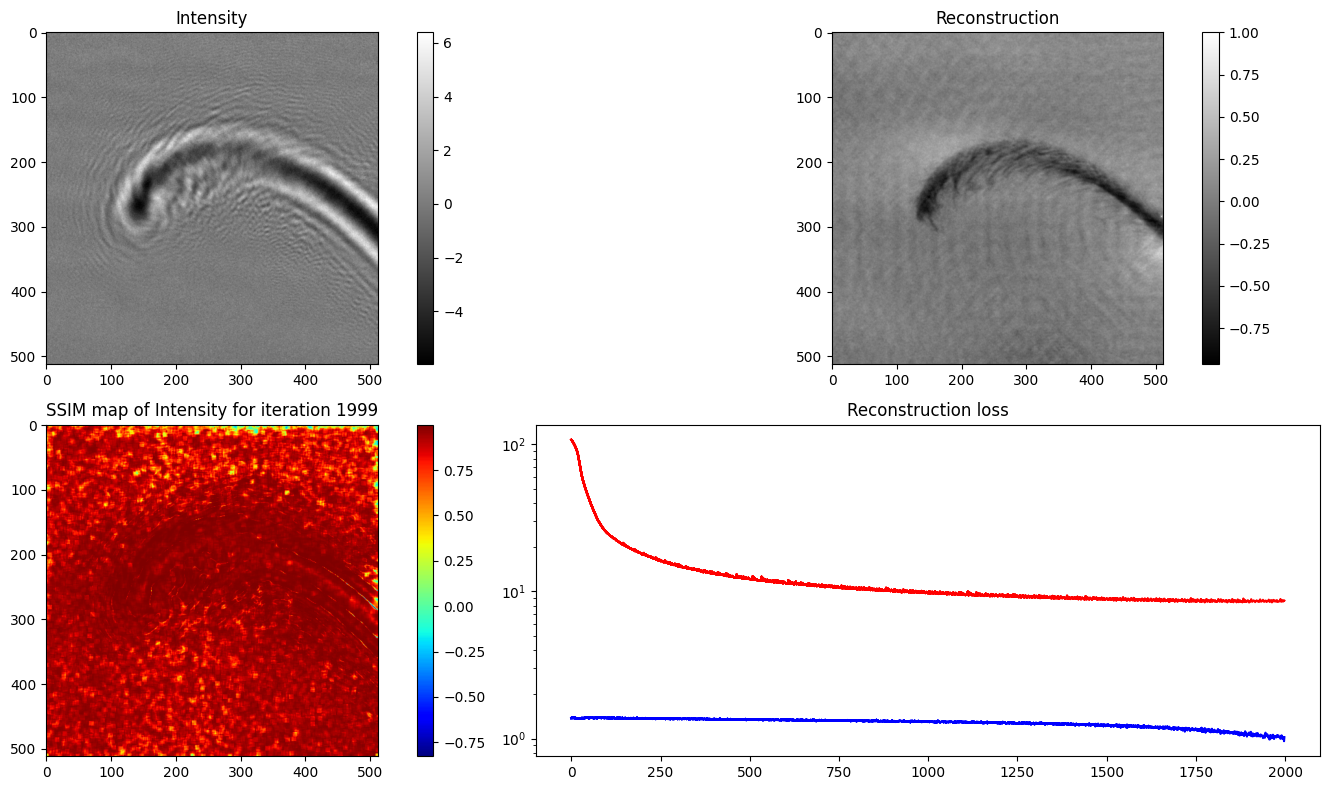

<Figure size 640x480 with 0 Axes>

Reconstruction Progress: 100%|█████████▉| 1999/2000 [01:44<00:00, 21.44it/s, D_loss=1.01, G_loss=8.63]

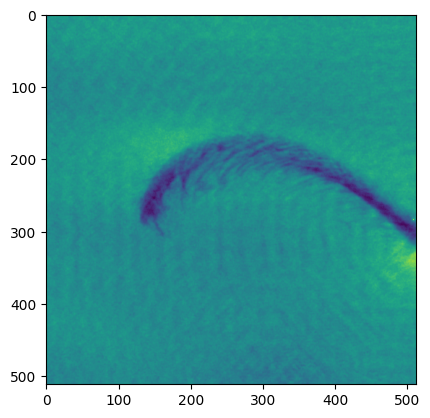

Reconstruction Progress: 100%|██████████| 2000/2000 [01:59<00:00, 21.44it/s, D_loss=1.01, G_loss=8.63]

In [ ]:
energy = 11
z = 7.8880960e-2
pv = 1.04735263e-7
abs_ratio = 0.001
iter_num = 2000
g_learning_rate = 1e-4
d_learning_rate = 1e-6
fname_data = './test_data/hologram_spider_hair.tiff'
data = tifffile.imread(fname_data)
data = nor_phase(data)
abs, phase = GANphase(data, energy, z, pv, abs_ratio = abs_ratio, 
                      iter_num=iter_num, 
                      g_learning_rate = g_learning_rate,
                      d_learning_rate = d_learning_rate).recon
plt.imshow(phase)
plt.show()
tifffile.imwrite('./test_results/spider_hair.tiff', phase)